import libraries 

In [36]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


Target Variable Construction

In [37]:
data = pd.read_csv('social_media_engagement_dataset.csv')

# 1) Log-transform engagement columns
target_cols = ["Likes", "Comments", "Shares", "Saves", "Views"]

def minmax_0_1(series):
    s_min = series.min()
    s_max = series.max()
    if s_max == s_min:
        return pd.Series(0.0, index=series.index)  # safe fallback for constant columns
    return (series - s_min) / (s_max - s_min)

for col in target_cols:
    log_col = f"log_{col.lower()}"
    data[log_col] = np.log1p(data[col])       # log(1 + x), safe for zeros
    data[log_col] = minmax_0_1(data[log_col]) # normalize each log feature to [0, 1]

# 2) Weighted score from normalized log features
data["Score_raw"] = (
    0.40 * data["log_views"] +
    0.20 * data["log_shares"] +
    0.20 * data["log_comments"] +
    0.15 * data["log_likes"] +
    0.05 * data["log_saves"]
)

# 3) Normalize final Score to [0, 1]
data["Score"] = minmax_0_1(data["Score_raw"])

# 4) Drop intermediate columns
cols_to_drop = target_cols + [f"log_{col.lower()}" for col in target_cols] + ["Score_raw", "Timestamp", "Engagement_Rate"]
data.drop(columns=cols_to_drop, inplace=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Platform        4913 non-null   object 
 1   Content_Type    4913 non-null   object 
 2   Category        4913 non-null   object 
 3   Follower_Count  4913 non-null   int64  
 4   Hour_of_Day     4913 non-null   int64  
 5   Day_of_Week     4913 non-null   object 
 6   Hashtag_Count   4913 non-null   int64  
 7   Content_Length  4913 non-null   int64  
 8   Sentiment       4913 non-null   object 
 9   Has_Media       4913 non-null   bool   
 10  Is_Verified     4913 non-null   bool   
 11  Score           4913 non-null   float64
dtypes: bool(2), float64(1), int64(4), object(5)
memory usage: 393.6+ KB


EDA

1) TARGET (Score)


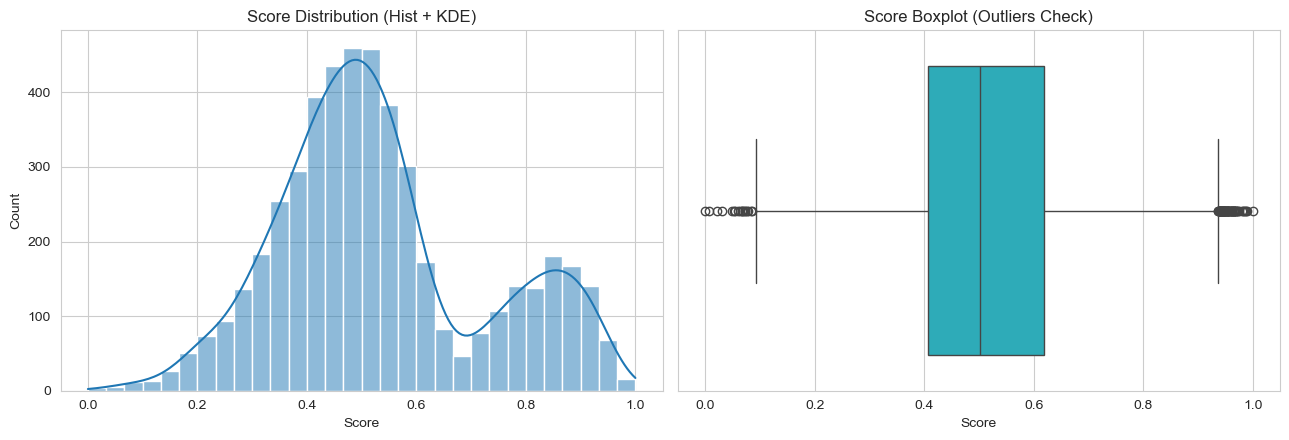

Skewness(Score): 0.4616
Basic stats:


,Score
mean,0.532982
median,0.501575
min,0.000000
max,1.000000
std,0.191031


--------------------------------------------------------------------------------


In [38]:
required_cols = [
    "Follower_Count", "Hour_of_Day", "Hashtag_Count", "Content_Length", "Score",
    "Platform", "Content_Type", "Category", "Day_of_Week", "Sentiment",
    "Has_Media", "Is_Verified"
]
missing_cols = [c for c in required_cols if c not in data.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

numerical_features = ["Follower_Count", "Hour_of_Day", "Hashtag_Count", "Content_Length", "Score"]
categorical_features = ["Platform", "Content_Type", "Category", "Day_of_Week", "Sentiment"]
boolean_features = ["Has_Media", "Is_Verified"]


def iqr_extremes(series, multiplier=3):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    extreme = s[(s < lower) | (s > upper)]
    return lower, upper, extreme


# 1) TARGET (Score)
print("1) TARGET (Score)")
score = data["Score"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(score, bins=30, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Score Distribution (Hist + KDE)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")

sns.boxplot(x=score, ax=axes[1], color="#17becf")
axes[1].set_title("Score Boxplot (Outliers Check)")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()

score_stats = score.agg(["mean", "median", "min", "max", "std"])
print(f"Skewness(Score): {score.skew():.4f}")
print("Basic stats:")
display(score_stats.to_frame("Score"))
print("-" * 80)




2) NUMERICAL FEATURES (Relationship with Score)


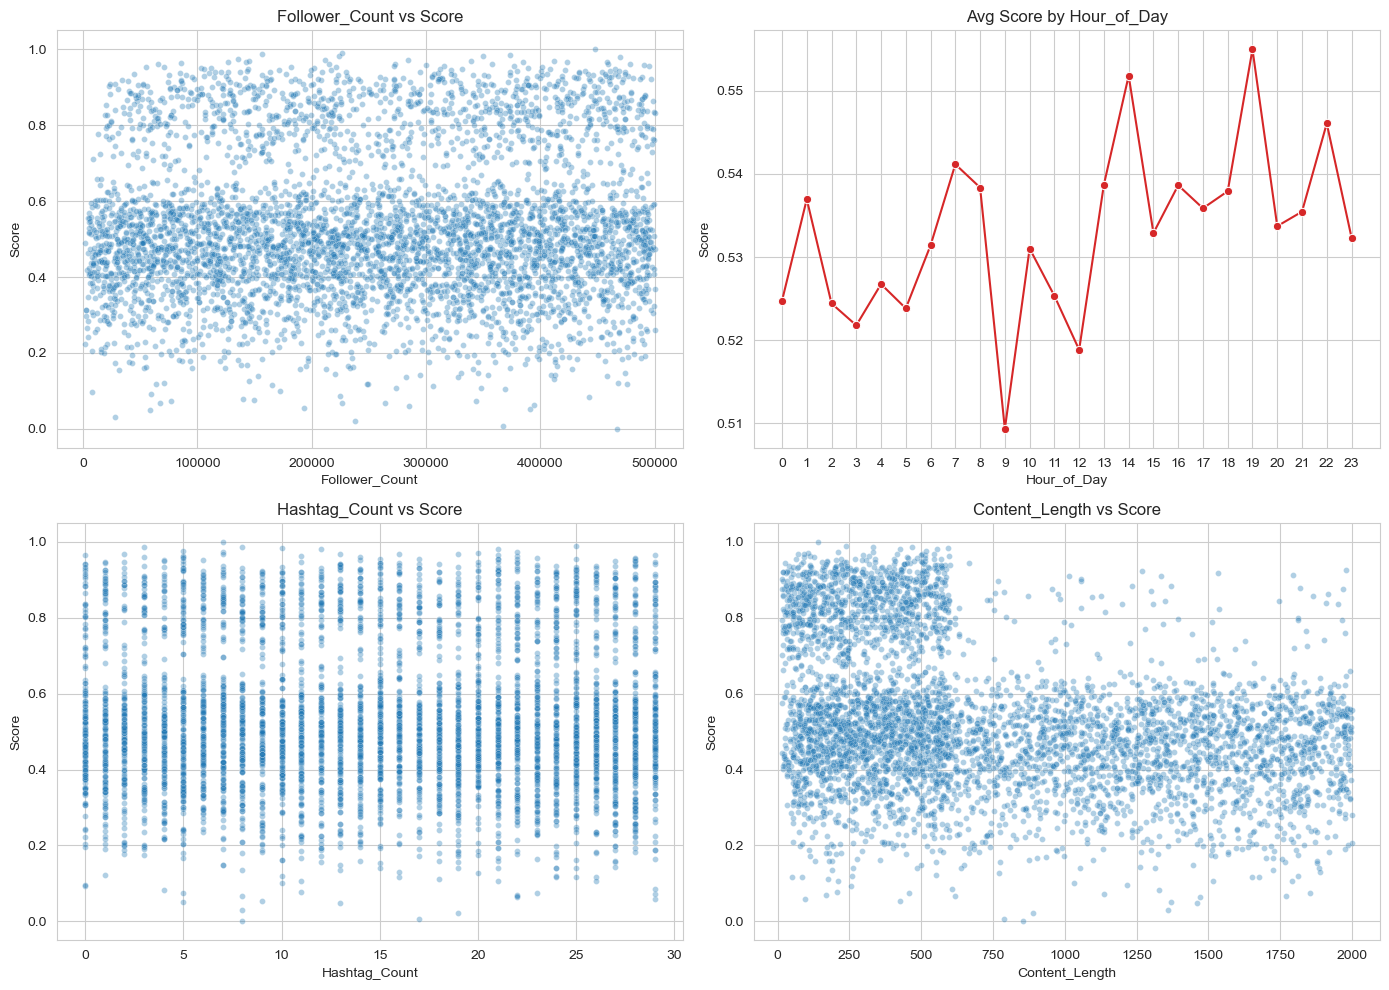

Correlations with Score:


,corr_with_score
Content_Length,-0.336292
Follower_Count,0.053066
Hashtag_Count,-0.003464


--------------------------------------------------------------------------------


In [39]:
# 2) NUMERICAL FEATURES (Relationship with Score)
print("2) NUMERICAL FEATURES (Relationship with Score)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=data, x="Follower_Count", y="Score", alpha=0.35, s=18, ax=axes[0, 0])
axes[0, 0].set_title("Follower_Count vs Score")

hourly_avg = data.groupby("Hour_of_Day", as_index=False)["Score"].mean().sort_values("Hour_of_Day")
sns.lineplot(data=hourly_avg, x="Hour_of_Day", y="Score", marker="o", ax=axes[0, 1], color="#d62728")
axes[0, 1].set_title("Avg Score by Hour_of_Day")
axes[0, 1].set_xticks(sorted(data["Hour_of_Day"].dropna().unique()))

sns.scatterplot(data=data, x="Hashtag_Count", y="Score", alpha=0.35, s=18, ax=axes[1, 0])
axes[1, 0].set_title("Hashtag_Count vs Score")

sns.scatterplot(data=data, x="Content_Length", y="Score", alpha=0.35, s=18, ax=axes[1, 1])
axes[1, 1].set_title("Content_Length vs Score")

plt.tight_layout()
plt.show()

num_corr = pd.Series(
    {
        "Follower_Count": data["Follower_Count"].corr(data["Score"]),
        "Hashtag_Count": data["Hashtag_Count"].corr(data["Score"]),
        "Content_Length": data["Content_Length"].corr(data["Score"]),
    }
).sort_values(key=np.abs, ascending=False)

print("Correlations with Score:")
display(num_corr.to_frame("corr_with_score"))
print("-" * 80)




3) CATEGORICAL FEATURES (Impact on Score)

Average Score by Platform:


,Platform,mean,count
0,TikTok,0.830076,701
1,YouTube,0.787576,474
2,Twitter,0.501122,990
3,Facebook,0.490411,976
4,Instagram,0.423469,1270
5,LinkedIn,0.300374,502


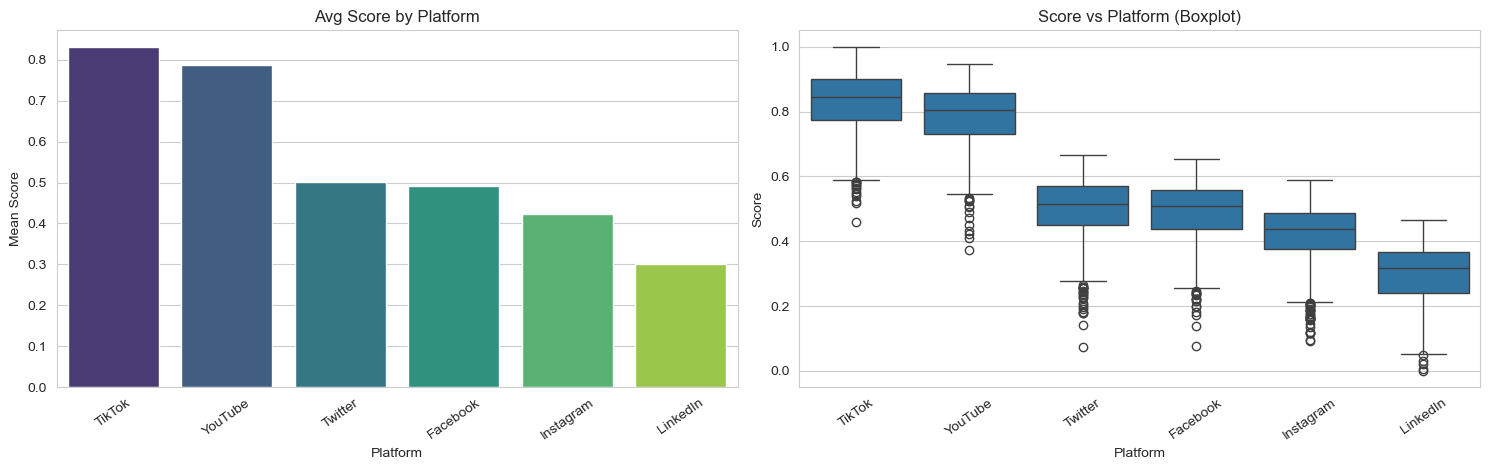


Average Score by Content_Type:


,Content_Type,mean,count
0,Stitch,0.832167,242
1,Duet,0.829421,228
2,Short,0.793188,119
3,Community Post,0.781519,133
4,Video,0.668985,593
5,Live,0.594558,357
6,Tweet,0.503741,237
7,Thread,0.498985,235
8,Retweet,0.496080,251
9,Story,0.454418,565


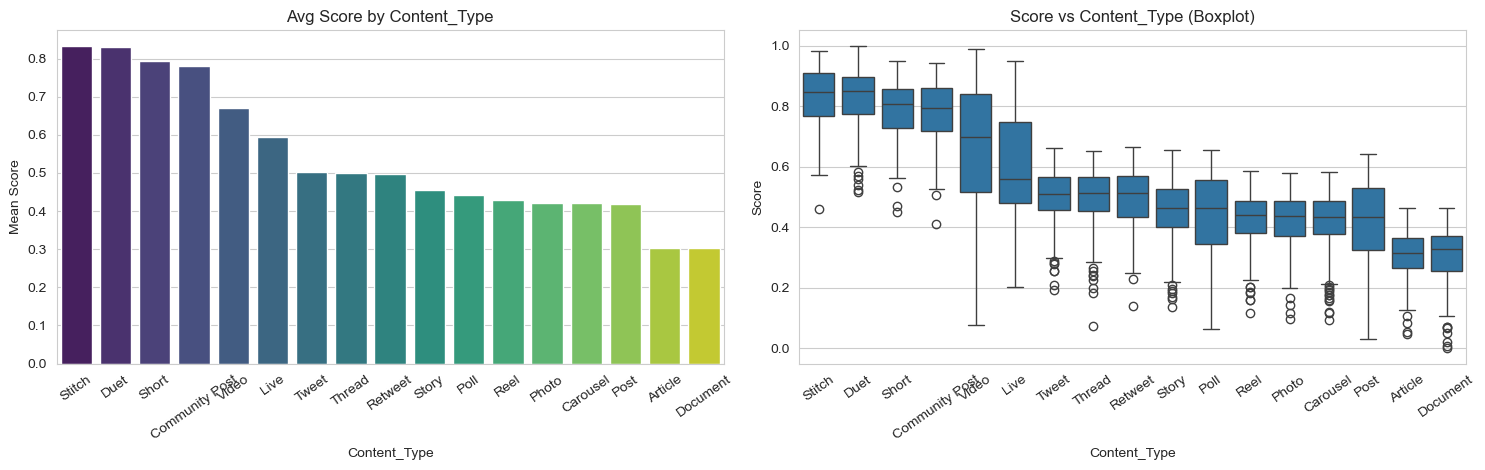


Average Score by Category:


,Category,mean,count
0,Health,0.552319,391
1,Education,0.547654,407
2,Travel,0.546068,388
3,Food,0.536136,405
4,Gaming,0.531675,468
5,Technology,0.531097,425
6,Entertainment,0.531036,423
7,Sports,0.529915,399
8,Fitness,0.527223,387
9,Lifestyle,0.523831,422


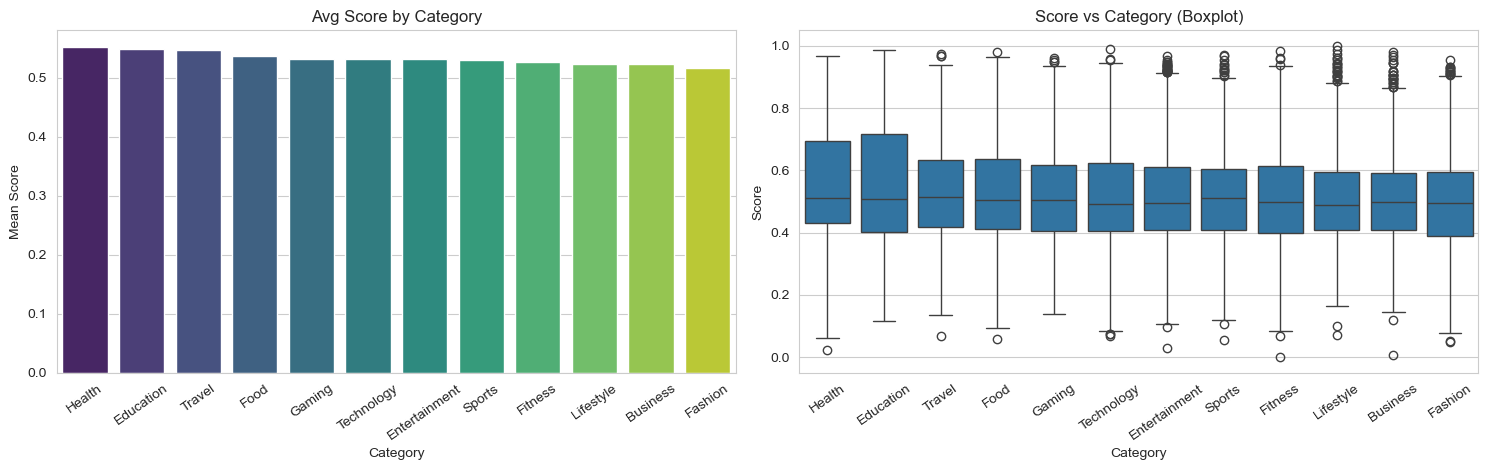


Average Score by Day_of_Week:


,Day_of_Week,mean,count
0,Monday,0.521866,703
1,Tuesday,0.539048,704
2,Wednesday,0.540254,720
3,Thursday,0.540218,706
4,Friday,0.528495,691
5,Saturday,0.524818,693
6,Sunday,0.535794,696


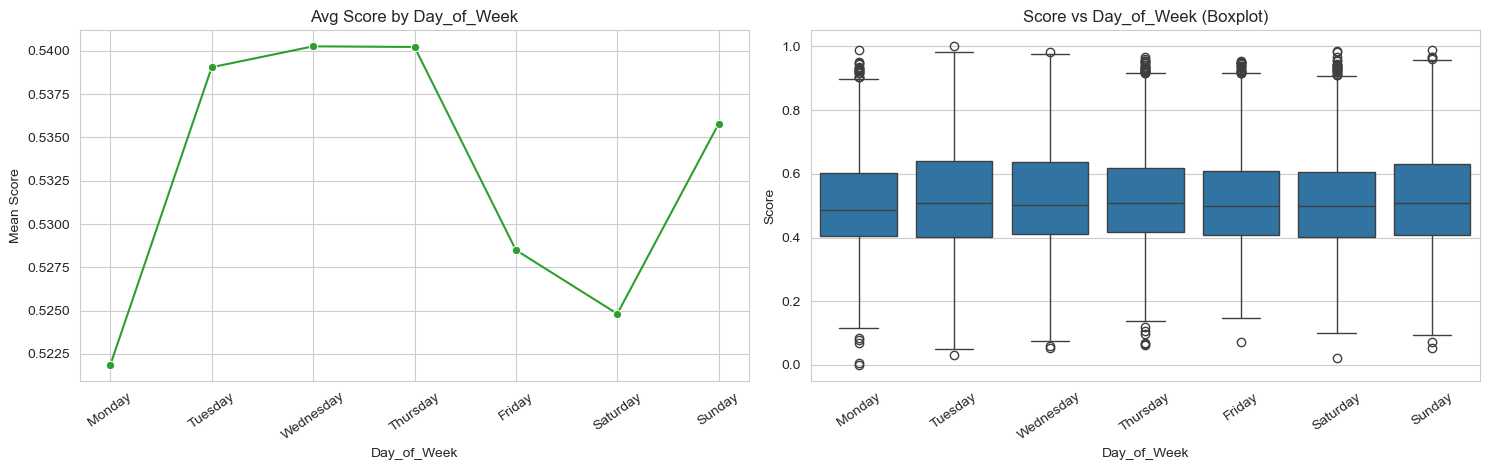


Average Score by Sentiment:


,Sentiment,mean,count
0,Positive,0.539219,2465
1,Neutral,0.529304,1718
2,Negative,0.520575,730


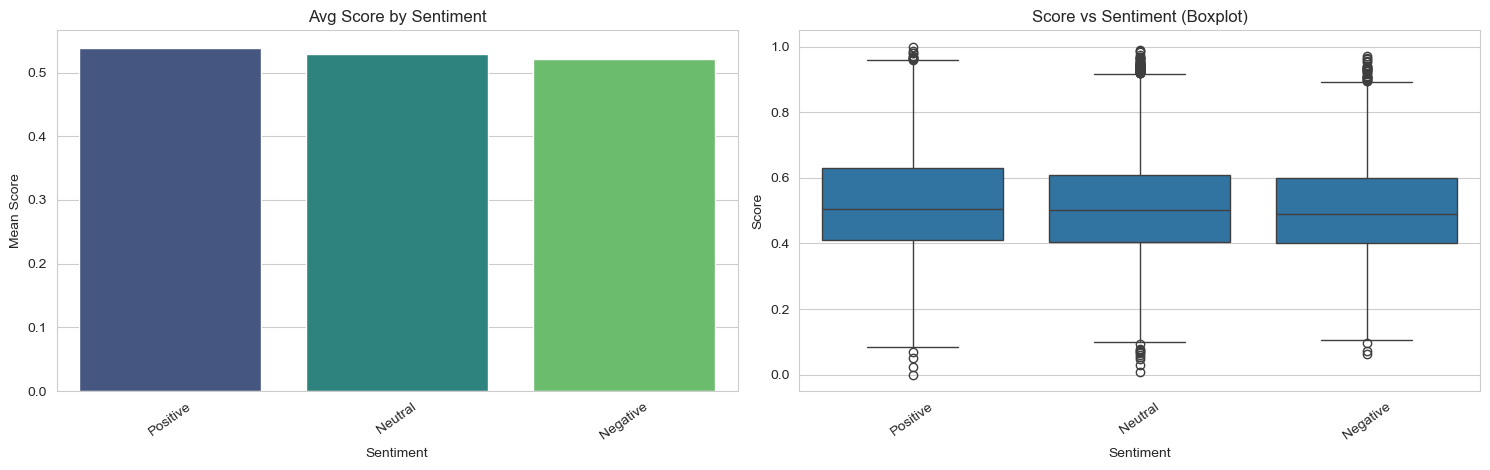

--------------------------------------------------------------------------------


In [40]:
# 3) CATEGORICAL FEATURES (Impact on Score)
print("3) CATEGORICAL FEATURES (Impact on Score)")
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

for col in categorical_features:
    if col == "Day_of_Week":
        order = [d for d in day_order if d in data[col].dropna().unique()]
        avg_df = (
            data.groupby(col, observed=False)["Score"]
            .agg(["mean", "count"])
            .reindex(order)
            .reset_index()
        )
    else:
        avg_df = (
            data.groupby(col, observed=False)["Score"]
            .agg(["mean", "count"])
            .sort_values("mean", ascending=False)
            .reset_index()
        )
        order = avg_df[col].tolist()

    print(f"\nAverage Score by {col}:")
    display(avg_df)

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

    if col == "Day_of_Week":
        sns.lineplot(data=avg_df, x=col, y="mean", marker="o", ax=axes[0], color="#2ca02c")
        axes[0].set_title(f"Avg Score by {col}")
    else:
        sns.barplot(data=avg_df, x=col, y="mean", ax=axes[0], hue=col, legend=False, palette="viridis")
        axes[0].set_title(f"Avg Score by {col}")

    axes[0].tick_params(axis="x", rotation=35)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Mean Score")

    sns.boxplot(data=data, x=col, y="Score", order=order, ax=axes[1])
    axes[1].set_title(f"Score vs {col} (Boxplot)")
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Score")

    plt.tight_layout()
    plt.show()

print("-" * 80)




4) BOOLEAN FEATURES

Mean Score by Has_Media:


,Has_Media,mean,count
0,False,0.531438,762
1,True,0.533265,4151


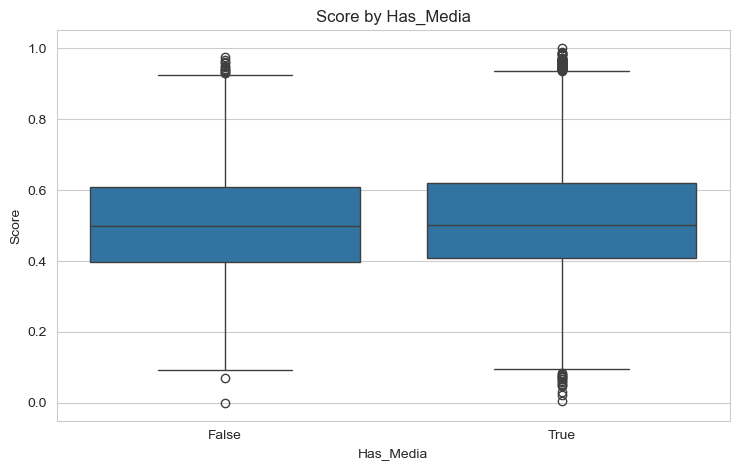


Mean Score by Is_Verified:


,Is_Verified,mean,count
0,False,0.532392,3630
1,True,0.534652,1283


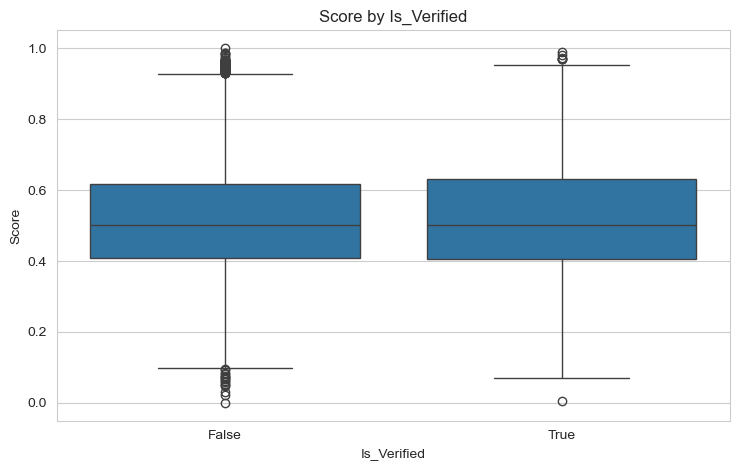

In [42]:
# 4) BOOLEAN FEATURES
print("4) BOOLEAN FEATURES")
for col in boolean_features:
    mean_df = (
        data.groupby(col, dropna=False)["Score"]
        .agg(["mean", "count"])
        .reset_index()
        .sort_values(col)
    )
    print(f"\nMean Score by {col}:")
    display(mean_df)

    plt.figure(figsize=(7.5, 4.8))
    sns.boxplot(data=data, x=col, y="Score", order=[False, True])
    plt.title(f"Score by {col}")
    plt.xlabel(col)
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

**INSIGHTS**

- The strongest driver of Score is Platform.
    Eta-squared impact: 0.7685 (very large).


- The second strongest driver is Content_Type.
    Eta-squared impact: 0.5970 (very large).


- Best platform for performance?
    TikTok (mean Score 0.8301), then YouTube (0.7876).
    Worst: LinkedIn (0.3004).


- Best content type?
    Stitch (0.8322), Duet (0.8294), Short (0.7932), Community Post (0.7815).
    Worst: Document (0.3039), Article (0.3041).


- Best posting time trend?
    Top hours: 19 (0.5550), 14 (0.5518), 22 (0.5461), 7 (0.5412), 13 (0.5387).
    Weakest hours: 9 (0.5093), 12 (0.5189), 3 (0.5218), 5 (0.5238), 2 (0.5244).


- Category, Day_of_Week, Sentiment effects are real but small.


- Interpretation In One Line
Performance (score) is primarily structured by platform and content format; audience size (followers), media flag, and verification status add only small incremental signal.